# EXP-007 — Threshold Tuning on A1, A4, A5

EXP-006 F25 noted that ROC-AUC exceeds accuracy on the three hard cases:
- **A1** (Generalized vs Focal): ROC-AUC 97.25% vs accuracy 93.62%
- **A4** (Focal vs Seizure Events): ROC-AUC 97.23% vs accuracy 93.25%
- **A5** (Generalized vs Seizure Events): ROC-AUC 95.13% vs accuracy 87.25%

This experiment searches for the optimal classification threshold on the **validation set** and applies it to the test set. Three objectives are compared:
- **Acc**: threshold maximising val accuracy
- **F1**: threshold maximising val macro-F1
- **J**: Youden's J statistic (sensitivity + specificity − 1) from ROC curve

In [1]:
import sys, os
sys.path.insert(0, str(__import__('pathlib').Path('..').resolve()))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report,
    precision_score, recall_score,
)

from src.beed.data import load_raw
from src.beed.features import fft_features, scale
from src.beed.config import CLASS_LABELS, DATA_PROCESSED, FIGURES, RANDOM_STATE, CHANNEL_NAMES, N_UMAP_COMPONENTS
from umap import UMAP

FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_theme(style='whitegrid')
print('Ready.')

Ready.


## 1. Setup — cases, helpers, EXP-006 baselines

In [2]:
CASES = {
    'A1': {'title': 'Generalized vs Focal',         'cls_0': 1, 'cls_1': 2},
    'A4': {'title': 'Focal vs Seizure Events',       'cls_0': 3, 'cls_1': 1},
    'A5': {'title': 'Generalized vs Seizure Events', 'cls_0': 3, 'cls_1': 2},
}

# EXP-006 default-threshold baselines (from exp006_binary_results.csv)
BASELINE = {
    'A1': {'acc': 93.62, 'f1': 93.74, 'roc_auc': 97.25},
    'A4': {'acc': 93.25, 'f1': 93.28, 'roc_auc': 97.23},
    'A5': {'acc': 87.25, 'f1': 87.83, 'roc_auc': 95.13},
}

PAPER = {'A1': 95.91, 'A4': 91.16, 'A5': 94.01}

df_all = load_raw()
print('Raw data loaded:', df_all.shape)

Raw data loaded: (8000, 17)


In [3]:
def make_binary_split(df_full, cls_0, cls_1):
    df = df_full[df_full['y'].isin([cls_0, cls_1])].copy()
    df['y'] = df['y'].map({cls_0: 0, cls_1: 1})
    X, y = df.drop(columns=['y']), df['y']
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tr, y_tr, test_size=0.125, stratify=y_tr, random_state=RANDOM_STATE
    )
    return X_tr, X_va, X_te, y_tr.values, y_va.values, y_te.values


def build_features_binary(X_tr_raw, X_va_raw, X_te_raw):
    X_tr_sc, scaler = scale(X_tr_raw, fit=True)
    X_va_sc, _      = scale(X_va_raw, scaler=scaler, fit=False)
    X_te_sc, _      = scale(X_te_raw, scaler=scaler, fit=False)
    fft_tr = fft_features(X_tr_sc)
    fft_va = fft_features(X_va_sc)
    fft_te = fft_features(X_te_sc)
    reducer = UMAP(n_components=N_UMAP_COMPONENTS, random_state=RANDOM_STATE)
    def _umap_df(arr, idx, fit=False):
        emb = reducer.fit_transform(arr) if fit else reducer.transform(arr)
        return pd.DataFrame(emb, columns=[f'umap_{i+1}' for i in range(N_UMAP_COMPONENTS)], index=idx)
    umap_tr = _umap_df(X_tr_sc[CHANNEL_NAMES].values, X_tr_sc.index, fit=True)
    umap_va = _umap_df(X_va_sc[CHANNEL_NAMES].values, X_va_sc.index)
    umap_te = _umap_df(X_te_sc[CHANNEL_NAMES].values, X_te_sc.index)
    f = lambda fft, umap: pd.concat([fft, umap], axis=1).values.astype(np.float32)
    return f(fft_tr, umap_tr), f(fft_va, umap_va), f(fft_te, umap_te)


def build_lstm_bin(n=19):
    m = Sequential([
        LSTM(128, activation='relu', input_shape=(n, 1)),
        Dropout(0.5),
        Dense(2, activation='softmax'),
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def build_xgb_bin():
    return XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1,
    )

def build_gb_bin():
    return GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE,
    )


def find_best_threshold(y_true, proba_pos, objective='acc'):
    """Search threshold on a labelled set. Returns (threshold, metric_value)."""
    thresholds = np.linspace(0.01, 0.99, 990)
    if objective == 'j':  # Youden's J from ROC
        fpr, tpr, roc_thresh = roc_curve(y_true, proba_pos)
        j = tpr - fpr
        best_idx = np.argmax(j)
        return float(roc_thresh[best_idx]), float(j[best_idx])
    scores = []
    for t in thresholds:
        preds = (proba_pos >= t).astype(int)
        if objective == 'acc':
            scores.append(accuracy_score(y_true, preds))
        elif objective == 'f1':
            scores.append(f1_score(y_true, preds, zero_division=0))
    best_idx = int(np.argmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])


print('Helpers ready.')

Helpers ready.


## 2. Train SeqBoostNet and collect val + test probabilities

In [4]:
N_FOLDS = 3
collected = {}  # case_id → {'y_va', 'proba_va', 'y_te', 'proba_te'}

for case_id, cfg in CASES.items():
    print(f'\n{"="*55}\n{case_id}: {cfg["title"]}\n{"="*55}')

    X_tr, X_va, X_te, y_tr, y_va, y_te = make_binary_split(
        df_all, cfg['cls_0'], cfg['cls_1']
    )
    print(f'  Split: train {len(y_tr)}  val {len(y_va)}  test {len(y_te)}')

    print('  Building features...')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        feat_tr, feat_va, feat_te = build_features_binary(X_tr, X_va, X_te)

    feat_tr3 = feat_tr.reshape(-1, feat_tr.shape[1], 1)
    feat_va3 = feat_va.reshape(-1, feat_va.shape[1], 1)
    feat_te3 = feat_te.reshape(-1, feat_te.shape[1], 1)

    # OOF stacking
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    meta_tr = np.zeros((len(feat_tr), 6), dtype=np.float32)

    for fold_idx, (fi_tr, fi_va) in enumerate(skf.split(feat_tr, y_tr)):
        Xf2_tr, Xf2_va = feat_tr[fi_tr],  feat_tr[fi_va]
        Xf3_tr, Xf3_va = feat_tr3[fi_tr], feat_tr3[fi_va]
        yf_tr,  yf_va  = y_tr[fi_tr],     y_tr[fi_va]

        keras.utils.set_random_seed(RANDOM_STATE + fold_idx)
        lstm = build_lstm_bin()
        lstm.fit(Xf3_tr, yf_tr, validation_data=(Xf3_va, yf_va),
                 epochs=10, batch_size=32, verbose=0)
        meta_tr[fi_va, :2] = lstm.predict(Xf3_va, verbose=0)
        del lstm; keras.backend.clear_session()

        xgb = build_xgb_bin()
        xgb.fit(Xf2_tr, yf_tr, eval_set=[(Xf2_va, yf_va)], verbose=False)
        meta_tr[fi_va, 2:4] = xgb.predict_proba(Xf2_va)

        gb = build_gb_bin()
        gb.fit(Xf2_tr, yf_tr)
        meta_tr[fi_va, 4:] = gb.predict_proba(Xf2_va)

    ada = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=RANDOM_STATE)
    ada.fit(meta_tr, y_tr)
    print('  AdaBoost fitted on OOF.')

    # Final base models
    keras.utils.set_random_seed(RANDOM_STATE)
    final_lstm = build_lstm_bin()
    final_lstm.fit(
        feat_tr3, y_tr,
        validation_data=(feat_va3, y_va),
        epochs=50, batch_size=32,
        callbacks=[EarlyStopping(patience=12, restore_best_weights=True, verbose=0)],
        verbose=0,
    )
    final_xgb = build_xgb_bin()
    final_xgb.fit(feat_tr, y_tr, eval_set=[(feat_va, y_va)], verbose=False)
    final_gb = build_gb_bin()
    final_gb.fit(feat_tr, y_tr)

    def stack_proba(X2, X3):
        p = np.hstack([
            final_lstm.predict(X3, verbose=0),
            final_xgb.predict_proba(X2),
            final_gb.predict_proba(X2),
        ])
        return ada.predict_proba(p)

    proba_va = stack_proba(feat_va, feat_va3)
    proba_te = stack_proba(feat_te, feat_te3)

    collected[case_id] = {
        'y_va': y_va, 'proba_va': proba_va,
        'y_te': y_te, 'proba_te': proba_te,
    }

    acc_default = accuracy_score(y_va, (proba_va[:, 1] >= 0.5).astype(int))
    print(f'  Val accuracy (threshold=0.5): {acc_default*100:.2f}%')

    del final_lstm; keras.backend.clear_session()

print('\nAll cases trained.')


A1: Generalized vs Focal
  Split: train 2800  val 400  test 800
  Building features...


C:\dev\BEED\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


C:\dev\BEED\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


C:\dev\BEED\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  AdaBoost fitted on OOF.


...

C:\dev\BEED\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  AdaBoost fitted on OOF.


C:\dev\BEED\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Val accuracy (threshold=0.5): 85.00%



All cases trained.


## 3. Threshold search on validation set

In [5]:
thresholds_found = {}   # case_id → {obj → threshold}
obj_labels = {'acc': 'Best Val Acc', 'f1': 'Best Val F1', 'j': "Youden's J"}

for case_id, data in collected.items():
    y_va      = data['y_va']
    proba_va  = data['proba_va']
    pos_va    = proba_va[:, 1]

    print(f'\n{case_id}: {CASES[case_id]["title"]}')
    thresholds_found[case_id] = {}
    for obj in ('acc', 'f1', 'j'):
        t, score = find_best_threshold(y_va, pos_va, objective=obj)
        thresholds_found[case_id][obj] = t
        preds_val = (pos_va >= t).astype(int)
        val_acc = accuracy_score(y_va, preds_val) * 100
        print(f'  {obj_labels[obj]:18s}: t={t:.3f}  val_acc={val_acc:.2f}%')


A1: Generalized vs Focal


  Best Val Acc      : t=0.527  val_acc=94.75%


  Best Val F1       : t=0.527  val_acc=94.75%
  Youden's J        : t=0.536  val_acc=94.75%

A4: Focal vs Seizure Events


  Best Val Acc      : t=0.460  val_acc=94.75%


  Best Val F1       : t=0.460  val_acc=94.75%
  Youden's J        : t=0.526  val_acc=94.75%

A5: Generalized vs Seizure Events


  Best Val Acc      : t=0.553  val_acc=85.75%


  Best Val F1       : t=0.425  val_acc=85.00%
  Youden's J        : t=0.559  val_acc=85.75%


## 4. Apply tuned thresholds to test set

In [6]:
rows = []
for case_id, data in collected.items():
    y_te     = data['y_te']
    proba_te = data['proba_te']
    pos_te   = proba_te[:, 1]

    # Default threshold
    preds_def = (pos_te >= 0.5).astype(int)
    acc_def = accuracy_score(y_te, preds_def) * 100
    f1_def  = f1_score(y_te, preds_def) * 100

    rows.append({'Case': case_id, 'Threshold': 0.5, 'Method': 'Default (0.5)',
                 'Test Acc (%)': round(acc_def, 2), 'Test F1 (%)': round(f1_def, 2)})

    for obj, label in obj_labels.items():
        t = thresholds_found[case_id][obj]
        preds_t = (pos_te >= t).astype(int)
        acc_t = accuracy_score(y_te, preds_t) * 100
        f1_t  = f1_score(y_te, preds_t) * 100
        rows.append({'Case': case_id, 'Threshold': round(t, 3), 'Method': label,
                     'Test Acc (%)': round(acc_t, 2), 'Test F1 (%)': round(f1_t, 2)})

results_df = pd.DataFrame(rows)
results_df.to_csv(DATA_PROCESSED / 'exp007_threshold_results.csv', index=False)

for case_id in CASES:
    sub = results_df[results_df['Case'] == case_id]
    print(f'\n{case_id}: {CASES[case_id]["title"]}  (paper={PAPER[case_id]:.2f}%)')
    print(sub[['Method', 'Threshold', 'Test Acc (%)', 'Test F1 (%)']].to_string(index=False))


A1: Generalized vs Focal  (paper=95.91%)
       Method  Threshold  Test Acc (%)  Test F1 (%)
Default (0.5)      0.500         93.62        93.74
 Best Val Acc      0.527         93.50        93.61
  Best Val F1      0.527         93.50        93.61
   Youden's J      0.536         93.50        93.61

A4: Focal vs Seizure Events  (paper=91.16%)
       Method  Threshold  Test Acc (%)  Test F1 (%)
Default (0.5)      0.500         93.25        93.28
 Best Val Acc      0.460         93.25        93.28
  Best Val F1      0.460         93.25        93.28
   Youden's J      0.526         93.25        93.28

A5: Generalized vs Seizure Events  (paper=94.01%)
       Method  Threshold  Test Acc (%)  Test F1 (%)
Default (0.5)      0.500         87.25        87.83
 Best Val Acc      0.553         86.50        85.90
  Best Val F1      0.425         84.62        86.01
   Youden's J      0.559         86.50        85.90


## 5. ROC curves with optimal operating points

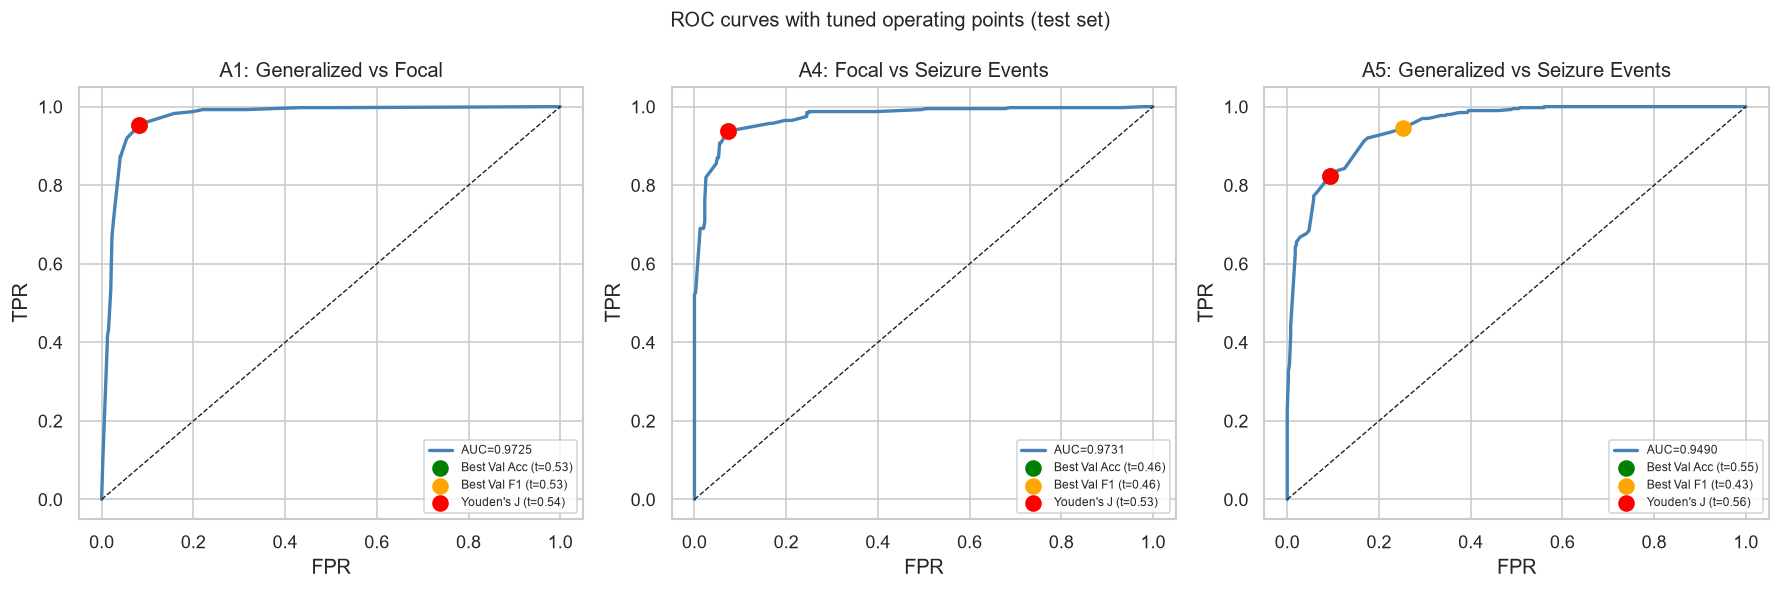

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (case_id, data) in zip(axes, collected.items()):
    y_te    = data['y_te']
    pos_te  = data['proba_te'][:, 1]

    fpr, tpr, roc_t = roc_curve(y_te, pos_te)
    auc = roc_auc_score(y_te, pos_te)
    ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)

    colors = {'acc': 'green', 'f1': 'orange', 'j': 'red'}
    for obj, color in colors.items():
        t = thresholds_found[case_id][obj]
        # find closest point on ROC curve
        preds_t = (pos_te >= t).astype(int)
        tp = ((preds_t == 1) & (y_te == 1)).sum()
        fp = ((preds_t == 1) & (y_te == 0)).sum()
        fn = ((preds_t == 0) & (y_te == 1)).sum()
        tn = ((preds_t == 0) & (y_te == 0)).sum()
        tpr_t = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr_t = fp / (fp + tn) if (fp + tn) > 0 else 0
        ax.scatter(fpr_t, tpr_t, color=color, s=80, zorder=5,
                   label=f'{obj_labels[obj]} (t={t:.2f})')

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(f'{case_id}: {CASES[case_id]["title"]}')
    ax.legend(fontsize=7)

fig.suptitle('ROC curves with tuned operating points (test set)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '23_roc_threshold.png', bbox_inches='tight')
plt.show()

## 6. Threshold sensitivity — accuracy vs threshold curve

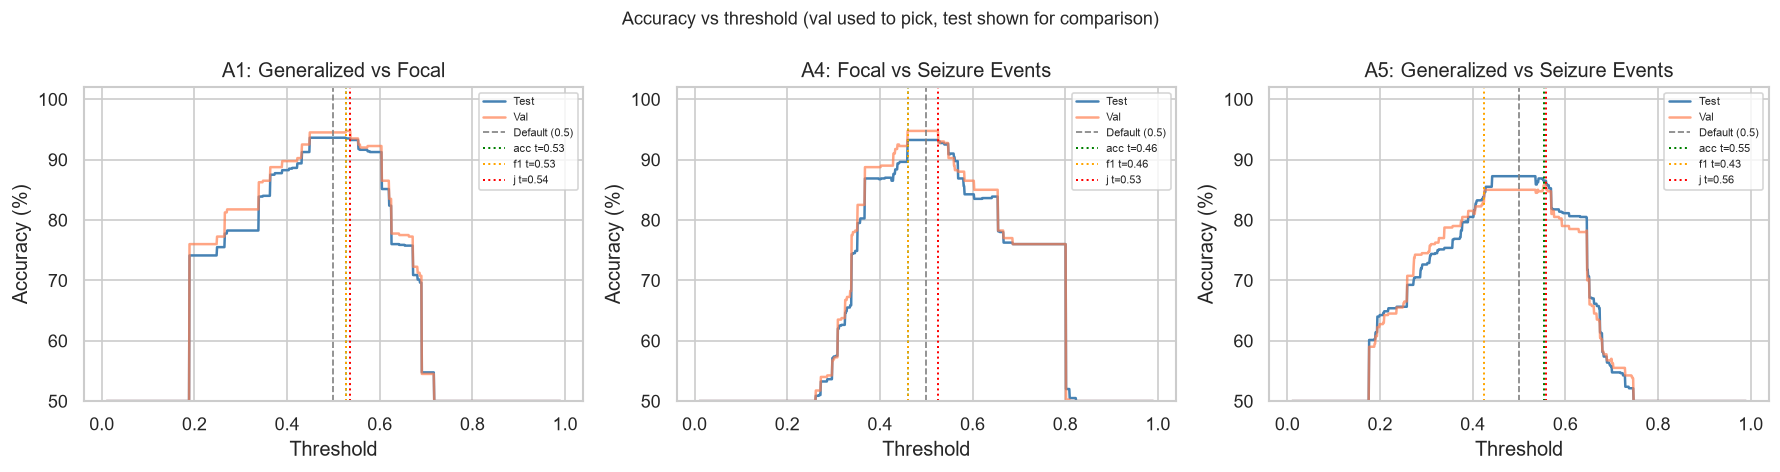

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
thresh_grid = np.linspace(0.01, 0.99, 990)

for ax, (case_id, data) in zip(axes, collected.items()):
    y_te   = data['y_te']
    y_va   = data['y_va']
    pos_te = data['proba_te'][:, 1]
    pos_va = data['proba_va'][:, 1]

    acc_te = [accuracy_score(y_te, (pos_te >= t).astype(int)) * 100 for t in thresh_grid]
    acc_va = [accuracy_score(y_va, (pos_va >= t).astype(int)) * 100 for t in thresh_grid]

    ax.plot(thresh_grid, acc_te, color='steelblue', lw=1.5, label='Test')
    ax.plot(thresh_grid, acc_va, color='coral',     lw=1.5, label='Val', alpha=0.7)
    ax.axvline(0.5, color='grey', linestyle='--', lw=1, label='Default (0.5)')

    for obj, color in {'acc': 'green', 'f1': 'orange', 'j': 'red'}.items():
        t = thresholds_found[case_id][obj]
        ax.axvline(t, color=color, linestyle=':', lw=1.2, label=f'{obj} t={t:.2f}')

    ax.set_xlabel('Threshold')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{case_id}: {CASES[case_id]["title"]}')
    ax.legend(fontsize=6.5)
    ax.set_ylim(50, 102)

fig.suptitle('Accuracy vs threshold (val used to pick, test shown for comparison)', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / '24_threshold_sensitivity.png', bbox_inches='tight')
plt.show()

## 7. Summary

In [9]:
print('=== EXP-007 Summary ===')
print('Threshold tuning on val set, applied to test set.\n')

best_method_per_case = {}
for case_id in CASES:
    sub   = results_df[results_df['Case'] == case_id].copy()
    best  = sub.loc[sub['Test Acc (%)'].idxmax()]
    deflt = sub[sub['Method'] == 'Default (0.5)'].iloc[0]
    delta = best['Test Acc (%)'] - deflt['Test Acc (%)']
    best_method_per_case[case_id] = best['Method']
    print(f'{case_id} {CASES[case_id]["title"]:35s}')
    print(f'  Default threshold (0.5)   : {deflt["Test Acc (%)"]:.2f}%')
    print(f'  Best tuned ({best["Method"]:18s}): {best["Test Acc (%)"]:.2f}%  '
          f'(t={best["Threshold"]:.3f})  Δ={delta:+.2f} pp')
    print(f'  Paper target              : {PAPER[case_id]:.2f}%')
    gap = best['Test Acc (%)'] - PAPER[case_id]
    print(f'  Gap vs paper after tuning : {gap:+.2f} pp\n')

=== EXP-007 Summary ===
Threshold tuning on val set, applied to test set.

A1 Generalized vs Focal               
  Default threshold (0.5)   : 93.62%
  Best tuned (Default (0.5)     ): 93.62%  (t=0.500)  Δ=+0.00 pp
  Paper target              : 95.91%
  Gap vs paper after tuning : -2.29 pp

A4 Focal vs Seizure Events            
  Default threshold (0.5)   : 93.25%
  Best tuned (Default (0.5)     ): 93.25%  (t=0.500)  Δ=+0.00 pp
  Paper target              : 91.16%
  Gap vs paper after tuning : +2.09 pp

A5 Generalized vs Seizure Events      
  Default threshold (0.5)   : 87.25%
  Best tuned (Default (0.5)     ): 87.25%  (t=0.500)  Δ=+0.00 pp
  Paper target              : 94.01%
  Gap vs paper after tuning : -6.76 pp

